Loaded 4 reactions:
  ENDF/B-VII.1: AR-40(N,TOT): 51296 points, E = [1.00e-11, 2.00e+01] MeV
  ENDF/B-VII.1: AR-40(N,EL)AR-40-L0: 20284 points, E = [1.00e-11, 2.00e+01] MeV
  ENDF/B-VII.1: AR-40(N,INL)AR-40: 248 points, E = [1.50e+00, 2.00e+01] MeV
  ENDF/B-VII.1: AR-40(N,G)AR-41: 33450 points, E = [1.00e-11, 2.00e+01] MeV


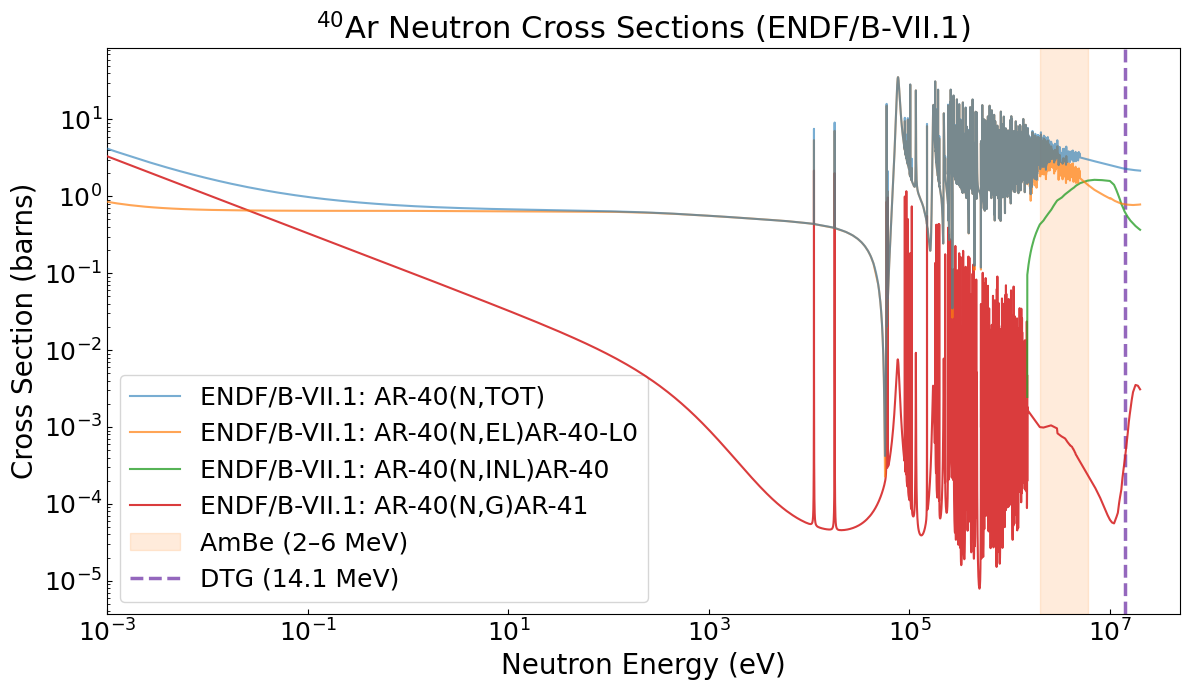

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parse ZVView-exported ENDF text file ─────────────────────────────
data_file = 'ar40_ENDF.txt'

sections = {}       # name -> (energy_MeV, xs_barns)
current_name = None
xs, ys = [], []

with open(data_file) as f:
    for line in f:
        line = line.strip()
        if line.startswith('#name:'):
            # Save previous section
            if current_name and xs:
                sections[current_name] = (np.array(xs), np.array(ys))
            current_name = line.split(':', 1)[1].strip()
            xs, ys = [], []
        elif line.startswith('#') or line.startswith('//') or not line:
            continue
        else:
            parts = line.split()
            if len(parts) >= 2:
                xs.append(float(parts[0]))
                ys.append(float(parts[1]))
    # Save last section
    if current_name and xs:
        sections[current_name] = (np.array(xs), np.array(ys))

print(f'Loaded {len(sections)} reactions:')
for name, (e, s) in sections.items():
    print(f'  {name}: {len(e)} points, E = [{e.min():.2e}, {e.max():.2e}] MeV')

# ── Plot ─────────────────────────────────────────────────────────────
labels = {
    'AR-40(N,TOT)':          ('Total',      'black'),
    'AR-40(N,EL)AR-40-L0':   ('Elastic',    'tab:blue'),
    'AR-40(N,INL)AR-40':     ('Inelastic',  'tab:green'),
    'AR-40(N,G)AR-41':       ('Capture',    'tab:red'),
}

fig, ax = plt.subplots(figsize=(12, 7))

i=100
for key, (e_mev, xs_b) in sections.items():
    i=i-10
    label, color = labels.get(key, (key, None))
    mask = xs_b > 0  # avoid log of zero
    ax.loglog(e_mev[mask] * 1e6, xs_b[mask], label=label, color=color, lw=1.5, zorder=i, alpha=(150-i)/100)

# ── Neutron source bands ─────────────────────────────────────────────
# AmBe: 2–6 MeV
ax.axvspan(2e6, 6e6, alpha=0.15, color='tab:orange', label='AmBe (2–6 MeV)')
# DTG: 14.1 MeV mono-energetic
ax.axvline(14.1e6, color='tab:purple', lw=2.5, ls='--', label='DTG (14.1 MeV)')

ax.set_xlabel('Neutron Energy (eV)', fontsize=20)
ax.set_ylabel('Cross Section (barns)', fontsize=20)
ax.set_title(r'$^{40}$Ar Neutron Cross Sections (ENDF/B-VII.1)', fontsize=22)
ax.set_xlim(1e-3, 5e7)
ax.tick_params(labelsize=18, direction='in', which='both')
ax.minorticks_on()
# ax.grid(True, which='major', ls='--', alpha=0.4)
ax.legend(fontsize=18, loc='best')
plt.tight_layout()
plt.show()

In [5]:
sections.items()

dict_items([('ENDF/B-VII.1: AR-40(N,TOT)', (array([1.00000e-11, 1.10304e-11, 1.21669e-11, ..., 1.98351e+01,
       1.98722e+01, 2.00000e+01]), array([39.0588 , 37.1928 , 35.4162 , ...,  2.16073,  2.16026,  2.15862]))), ('ENDF/B-VII.1: AR-40(N,EL)AR-40-L0', (array([1.00000e-11, 1.10304e-11, 1.21669e-11, ..., 1.95592e+01,
       1.98351e+01, 2.00000e+01]), array([5.86053 , 5.58308 , 5.31905 , ..., 0.781403, 0.782968, 0.783903]))), ('ENDF/B-VII.1: AR-40(N,INL)AR-40', (array([ 1.49774,  1.4978 ,  1.5    ,  1.54213,  1.5783 ,  1.61958,
        1.665  ,  1.7212 ,  1.75   ,  1.8322 ,  1.92628,  2.     ,
        2.12934,  2.17428,  2.271  ,  2.42421,  2.58775,  2.5878 ,
        2.59332,  2.60422,  2.62548,  2.64556,  2.68364,  2.73231,
        2.74689,  2.77372,  2.8409 ,  2.89105,  2.90275,  2.96595,
        3.     ,  3.06541,  3.14127,  3.14353,  3.21439,  3.21554,
        3.2892 ,  3.2893 ,  3.2972 ,  3.31257,  3.34158,  3.35299,
        3.36717,  3.41242,  3.45099,  3.47274,  3.55186,  3.5